# Program - cn_pt

**Purpose**

Read TaiESM hindcast simulation data. Given a variable and lat/lon, plot time-pressure cross-section.

**Content**
- read data
- plot cn_pt

**Author:** Yi-Hsuan Chen (yihsuan@umich.edu)

**Date:** 

**Reference program:**



In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Functions

## select_region_ds

In [2]:
##################
##################
##################
def select_region_ds(ds,
                  region="lat_lon",
                  lat=None, lon=None, 
                 ):

    func_name = "select_ds_region"
    
    #--- given the lat/lon range of a region
    if (region == "NE_CA"):
        #lowerlon=235; upperlon=245; lowerlat=28; upperlat=35
        lowerlon=225; upperlon=250; lowerlat=24; upperlat=40

    elif (region == "DYCOMS"): 
        #--- reference: Eyeballing in Fig. 1 in Stevens et al. (2007, MWR)
        region_name = "DYCOMS (29.5-33N, 120-123.5W)"
        lowerlat =  29.5   # 29.5N
        upperlat =  33     # 33N
        lowerlon =  236.5  # 123.5W
        upperlon =  240    # 120W

    elif (region == "lat_lon"): 
        if lat is None or lon is None:
            error_msg = f"ERROR: function [{func_name}] needs lat [{lat}] and lon [{lon}] when region='lat_lon'"
            raise KeyError(error_msg)
    
    else:
        lowerlon=-1000; upperlon=1000; lowerlat=-1000; upperlat=1000

    #--- select for in the given region
    if (region == "lat_lon"):
        lat_index, lon_index = get_lat_lon_indexes(ds, lat, lon)
        ds_region = ds.isel(lat=lat_index, lon=lon_index)

    else:
        lon_slice = slice(lowerlon, upperlon)
        lat_slice = slice(lowerlat, upperlat)
        ds_region = ds.sel(lat=lat_slice, lon=lon_slice)
    
    return ds_region

##################
##################
##################
def get_lat_lon_indexes(ds, lat, lon):
    lat_index = abs(ds['lat'] - lat).argmin().item()
    lon_index = abs(ds['lon'] - lon).argmin().item()

    return lat_index, lon_index

#-----------
# do_test
#-----------

do_test="111"
#do_test=False

if (do_test == "111"):
    choice = "custom_Ttend_3hr"
    icdate = "20010710"
    ds1 = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=5)
    
    lat=31.5 ; lon=236.5
    
    ds1_region = select_region_ds(ds1, region="lat_lon", lat=lat, lon=lon)

    #ds1_region

## read_hindcast_icdate_lat_lon

In [3]:
def read_hindcast_icdate_lat_lon(icdate, 
    lat=31.5, lon=236.5,
    ):

    file_dates = 5

    #--- read datasets
    choice = "custom_Ttend_3hr"
    ds_Ttend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_state_3hr"
    ds_state = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    choice = "custom_Qtend_3hr"
    ds_Qtend = read_data.read_TaiESM1_hindcast_icdate_files(choice, icdate, file_dates=file_dates)

    #--- diagnose variables in all ds
    yhc.diagnose_var(ds_state, ["play"])
    yhc.diagnose_var(ds_Ttend, ["DT_SUM_PHYS"])
    yhc.diagnose_var(ds_Qtend, ["DQV_SUM_PHYS", "DQL_SUM_PHYS"])

    #--- get data at the given lat/lon
    ds_Ttend_latlon = select_region_ds(ds_Ttend, region="lat_lon", lat=lat, lon=lon)
    ds_Qtend_latlon = select_region_ds(ds_Qtend, region="lat_lon", lat=lat, lon=lon)
    ds_state_latlon = select_region_ds(ds_state, region="lat_lon", lat=lat, lon=lon)

    return ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon

#-----------
# do_test
#-----------

do_test="111"
#do_test=False

if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate)

#ds_state_latlon
#ds_Ttend_latlon
#ds_Qtend_latlon

## get_plot_settings

In [7]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

################
################
################
def get_plot_settings(var: xr.DataArray, var_name: str):
    """
    Get plot settings (cmap, levels, long_name, units, and cbar_label) for a given variable.

    Parameters:
    - var: xarray.DataArray
        The variable to be plotted.
    - var_name: str
        The name of the variable.

    Returns:
    - settings: dict
        A dictionary with plot settings for the given variable.
    """
    # Default settings in case attributes are missing
    default_settings = {
        "cmap": "viridis",
        "levels": None,  # Will be determined dynamically if possible
        "norm": None, 
        "norm_option": None, 
        "long_name": var_name,  # Use var_name if long_name is missing
        "units": "Unknown Units",
        "cbar_label": f"{var_name} (Unknown Units)"
    }

    # Predefined variable settings (can be extended)
    ttend_min = -30 ; ttend_max = 20 ; ttend_num_levels = 11
    variable_settings = {
        "TTEND_TOT": {"cmap": "RdBu_r", 
                      #"levels":np.linspace(ttend_min, ttend_max, ttend_num_levels) ,
                      #"norm": mcolors.TwoSlopeNorm(vmin=ttend_min, vcenter=0, vmax=ttend_max),
                      #"norm_option" : "auto", 
                     },
        "QVTEND_TOT": {"cmap": "BrBG_r", 
                      },
        "QLTEND_TOT": {"cmap": "BrBG_r", 
                      },
        "T": {"cmap": "coolwarm"},
        "Q": {"cmap": "YlGnBu"},
        "CLDLIQ": {"cmap": "viridis"},
        "P": {"cmap": "RdBu"}
    }
    
    # Extract attributes
    long_name = var.attrs.get("long_name", default_settings["long_name"])
    units = var.attrs.get("units", default_settings["units"])

    # Determone cmap, levels, and norm
    cmap, levels, norm = get_cmap_levels_norm (var_name, variable_settings, default_settings, var)
    
    if var_name in ["MPDT", "MACPDT", "DTV", "DT_SUM_PHYS", "DTCORE"]:
        cmap, levels, norm = get_cmap_levels_norm ("TTEND_TOT", variable_settings, default_settings, var)  
    elif var_name in ["PTEQ", "MACPDQ", "MPDQ", "VD01", "DQVCORE", "DQV_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QVTEND_TOT", variable_settings, default_settings, var)
    elif var_name in ["PTECLDLIQ", "MACPDLIQ", "MPDLIQ", "VDCLDLIQ", "DQLCORE", "DQL_SUM_PHYS"]:
        cmap, levels, norm = get_cmap_levels_norm ("QLTEND_TOT", variable_settings, default_settings, var)
    
    # Construct colorbar label
    cbar_label = f"{long_name} ({units})"

    return {
        "norm":norm, 
        ###
        "cmap": cmap,
        "levels": levels,
        "long_name": long_name,
        "units": units,
        "cbar_label": cbar_label
    }

################
################
################
def get_nice_contour_levels(var_data, num_levels=15):
    if np.issubdtype(var_data.dtype, np.number):  # Ensure it's numeric
        vmin, vmax = np.nanmin(var_data), np.nanmax(var_data)

        # Round vmin/vmax based on magnitude
        magnitude = 10 ** np.floor(np.log10(vmax - vmin))  # Order of magnitude
        vmin = np.floor(vmin / magnitude) * magnitude
        vmax = np.ceil(vmax / magnitude) * magnitude

        # Use MaxNLocator to find nice levels
        locator = mticker.MaxNLocator(nbins=num_levels - 1, steps=[1, 2, 2.5, 5, 10])
        levels = locator.tick_values(vmin, vmax)
    else:
        levels = default_settings["levels"]  # Use default if non-numeric

    return levels

################
################
################
def get_cmap_levels_norm(var_name, variable_settings, default_settings, var=None):
    """
    Retrieve colormap, contour levels, and norm settings for a given variable.

    Parameters:
        var_name (str): Name of the variable.
        variable_settings (dict): Dictionary with variable-specific settings.
        default_settings (dict): Dictionary with default settings.
        var (xarray.DataArray or numpy array, optional): Data array for computing levels dynamically.

    Returns:
        tuple: (cmap, levels, norm)
    """
    # Determine colormap
    cmap = variable_settings.get(var_name, {}).get("cmap", default_settings["cmap"])
    
    # Determine contour levels
    levels = variable_settings.get(var_name, {}).get("levels", default_settings["levels"])
    if levels is None and var is not None:
        var_data = var.values
        levels = get_nice_contour_levels(var_data)

    # Determine norm
    norm_option = variable_settings.get(var_name, {}).get("norm_option", default_settings["norm_option"])
    if norm_option == "auto":
        norm = mcolors.TwoSlopeNorm(vmin=np.min(levels), vcenter=0, vmax=np.max(levels))
    else:
        norm = variable_settings.get(var_name, {}).get("norm", default_settings["norm"])

    return cmap, levels, norm

## get_var_data

In [8]:
#ds_Ttend_latlon

In [9]:
def get_var_data(ds: xr.Dataset, var_name: str):
    
    var_da = ds[var_name]  # Get the variable data as a numpy array
    var_da = yhc.unit_convert(var_da)
    settings = get_plot_settings(var_da, var_name)

    return var_da, settings

#-----------
# do_test
#-----------

do_test="111"
if (do_test == "111"):
    icdate = "20010710"
    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate)

    var_name = "OMEGA"
    var_da, settings = get_var_data (ds_state_latlon, var_name=var_name)

    var_name = "TTEND_TOT"
    #var_da, settings = get_var_data (ds_Ttend_latlon, var_name=var_name)

    var_name = "QVTEND_TOT"
    #var_da, settings = get_var_data (ds_Qtend_latlon, var_name=var_name)
    
#print(settings)

## plot_time_lev_contour

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import cftime
from scipy import interpolate

def plot_time_lev_contour(ax, ds, var_name, play, time_interval_hours=12, minor_time_interval_hours=3, title=None):
    """
    Plot a time vs. pressure contour plot for a given variable in the dataset.

    Parameters:
    - ax: matplotlib Axes object
        The axes on which to plot.
    - ds: xarray.Dataset
        The dataset containing the variable to plot.
    - var_name: str
        The variable name to plot (e.g., "T", "Q", "P").
    - play: xarray.DataArray
        The pressure levels corresponding to the data.
    - time_interval_hours: int, optional
        The interval for the x-axis ticks (default is 12 hours).
    - minor_time_interval_hours: int, optional
        The interval for minor ticks on the x-axis (default is 6 hours).
    - title: str, optional
        The title for the plot (default is None).
    """
    # Get da & plot settings for the variable
    var_da, settings = get_var_data (ds, var_name=var_name)

    # Get plot settings for the variable
    cmap = settings["cmap"]
    levels = settings["levels"]
    long_name = settings["long_name"]
    units = settings["units"]
    cbar_label = settings["cbar_label"]  # This now contains long_name (units)
    norm = settings["norm"]
    
    # Extract lat and lon directly from ds and format to two decimal places
    lat = var_da.lat.values
    lon = var_da.lon.values
    lat_str = f"{lat:.2f}"
    lon_str = f"{lon:.2f}"

    # Create a title with lat/lon if not provided
    if title is None:
        title = f"lat={lat_str}, lon={lon_str}"

    # Interpolate variable to the same pressure level as play[0]
    play_0 = play[0, :]  # Take the pressure levels at the first time step (1D)
    var_data = var_da.values  # Get the variable data as a numpy array

    # Create interpolation function for each time step
    interpolated_data = []
    for t in range(len(ds["time"].values)):
        interp_func = interpolate.interp1d(play[t, :], var_data[t, :], kind="linear", fill_value="extrapolate")
        interpolated_data.append(interp_func(play_0))  # Interpolate to play_0 levels

    # Stack interpolated data into a 2D array (time x lev)
    interpolated_data = np.stack(interpolated_data)

    # Select the first level from play (assuming you're interested in the first pressure level)
    play_1d = play_0  # Using play_0 as the pressure levels for the contour plot

    # Convert time to numeric values (0 to len(time))
    time_numeric = np.arange(len(ds["time"].values))

    # Plot the contour
    if (norm is not None):
        cont = ax.contourf(time_numeric, play_1d, interpolated_data.T, levels=levels, cmap=cmap, norm=norm)
    else:
        cont = ax.contourf(time_numeric, play_1d, interpolated_data.T, levels=levels, cmap=cmap)
    
    # Set the title with adjusted position (a bit higher)
    ax.set_title(title, pad=20)

    # Set x-axis and y-axis labels
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Pressure (hPa)')

    # Reverse the y-axis so that 1000 hPa will be at the bottom
    ax.invert_yaxis()

    # Set the x-axis ticks and labels for time
    time_ticks = np.arange(0, len(time_numeric), time_interval_hours)
    ax.set_xticks(time_ticks)
    
    # Assign the x-axis labels from cftime (for time values)
    time_labels = [t.strftime('%m%d_%H') for t in ds["time"].isel(time=time_ticks).values]
    ax.set_xticklabels(time_labels)

    # Add grid lines    
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

    # Add minor ticks
    ax.minorticks_on()
    ax.tick_params(which='minor', length=4, color='gray')
    minor_time_ticks = np.arange(0, len(time_numeric), minor_time_interval_hours)
    ax.set_xticks(minor_time_ticks, minor=True)

    # Add colorbar
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label(cbar_label)

    # Add long_name in the upper left and units in the upper right
    #ax.text(0, 1.05, f"{long_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(0, 1.05, f"{var_name}", transform=ax.transAxes, fontsize=12, verticalalignment='top')
    ax.text(1, 1.05, f"{units}", transform=ax.transAxes, fontsize=12, horizontalalignment='right', verticalalignment='top')

    return ax


## plot_panel

In [11]:
import matplotlib.pyplot as plt

def plot_panel(ds_dict, var_list, play_pt):
    """
    Creates a panel plot with 2 columns and adjusts rows dynamically based on var_list.

    Parameters:
        ds_dict (dict): Dictionary containing dataset objects with keys as dataset names.
        var_list (list): List of tuples (dataset_key, variable_name) to plot.
        play_pt: Additional parameter passed to plot_time_lev_contour.
    """
    num_vars = len(var_list)  # Determine the number of plots needed
    num_cols = 2
    num_rows = (num_vars + 1) // num_cols  # Calculate required rows

    # Create a figure with appropriate size
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 5 * num_rows))
    axes = axes.flatten()  # Flatten axes for easier indexing

    # Plot each variable in a different panel
    for i, (ds_key, var_name) in enumerate(var_list):
        plot_time_lev_contour(axes[i], ds_dict[ds_key], var_name, play_pt)
        #axes[i].set_title(var_name)

    # Remove extra unused subplots
    for j in range(len(var_list), num_rows * num_cols):
        fig.delaxes(axes[j])  

    # Adjust layout
    plt.tight_layout()
    plt.show()


## plot_time_lev_contour_panel

In [12]:
def plot_time_lev_contour_panel(icdate, lat, lon,
                                var_group,
                               ):

    ds_state_latlon, ds_Ttend_latlon, ds_Qtend_latlon = read_hindcast_icdate_lat_lon(icdate, lat=lat, lon=lon)
    
    play_pt = ds_state_latlon['play']
    
    ds_dict = {
        "state": ds_state_latlon,
        "Ttend": ds_Ttend_latlon,
        "Qtend": ds_Qtend_latlon
    }

    if (var_group == "T"):
        var_list = [
            ("state", "T"),
            ("Ttend", "TTEND_TOT"),
            ("Ttend", "DTV"),
            ("Ttend", "MACPDT"),
            ("Ttend", "DT_SUM_PHYS"),
            ]

    elif (var_group == "QV"):
        var_list = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ("Qtend", "VD01"),
            ("Qtend", "MACPDQ"),
            ("Qtend", "PTEQ"),
            ("Qtend", "DQV_SUM_PHYS"),
            ]

    elif (var_group == "QL"):
        var_list = [
            ("state", "CLDLIQ"),
            ("Qtend", "QLTEND_TOT"),
            ("Qtend", "VDCLDLIQ"),
            ("Qtend", "MACPDLIQ"),
            ("Qtend", "PTECLDLIQ"),
            ("Qtend", "DQL_SUM_PHYS"),
            ]
    
    elif (var_group == "test"):
        var_list = [
            ("state", "Q"),
            ("Qtend", "QVTEND_TOT"),
            ]
    plot_panel(ds_dict, var_list, play_pt)

#-----------
# do_test
#-----------

do_test="112"
if (do_test == "111"):
    icdate = "20010711"
    lat=31.5 ;  lon=236.5

    plot_time_lev_contour_panel(icdate, lat, lon, var_group="T")
    plot_time_lev_contour_panel(icdate, lat, lon, var_group="QV")
    #plot_time_lev_contour_panel(icdate, lat, lon, var_group="test")
    plot_time_lev_contour_panel(icdate, lat, lon, var_group="QL")

# Plot

## set icdate and lat/lon

In [13]:
icdate = "20010711"
lat=31.5 ;  lon=236.5

## Plot T

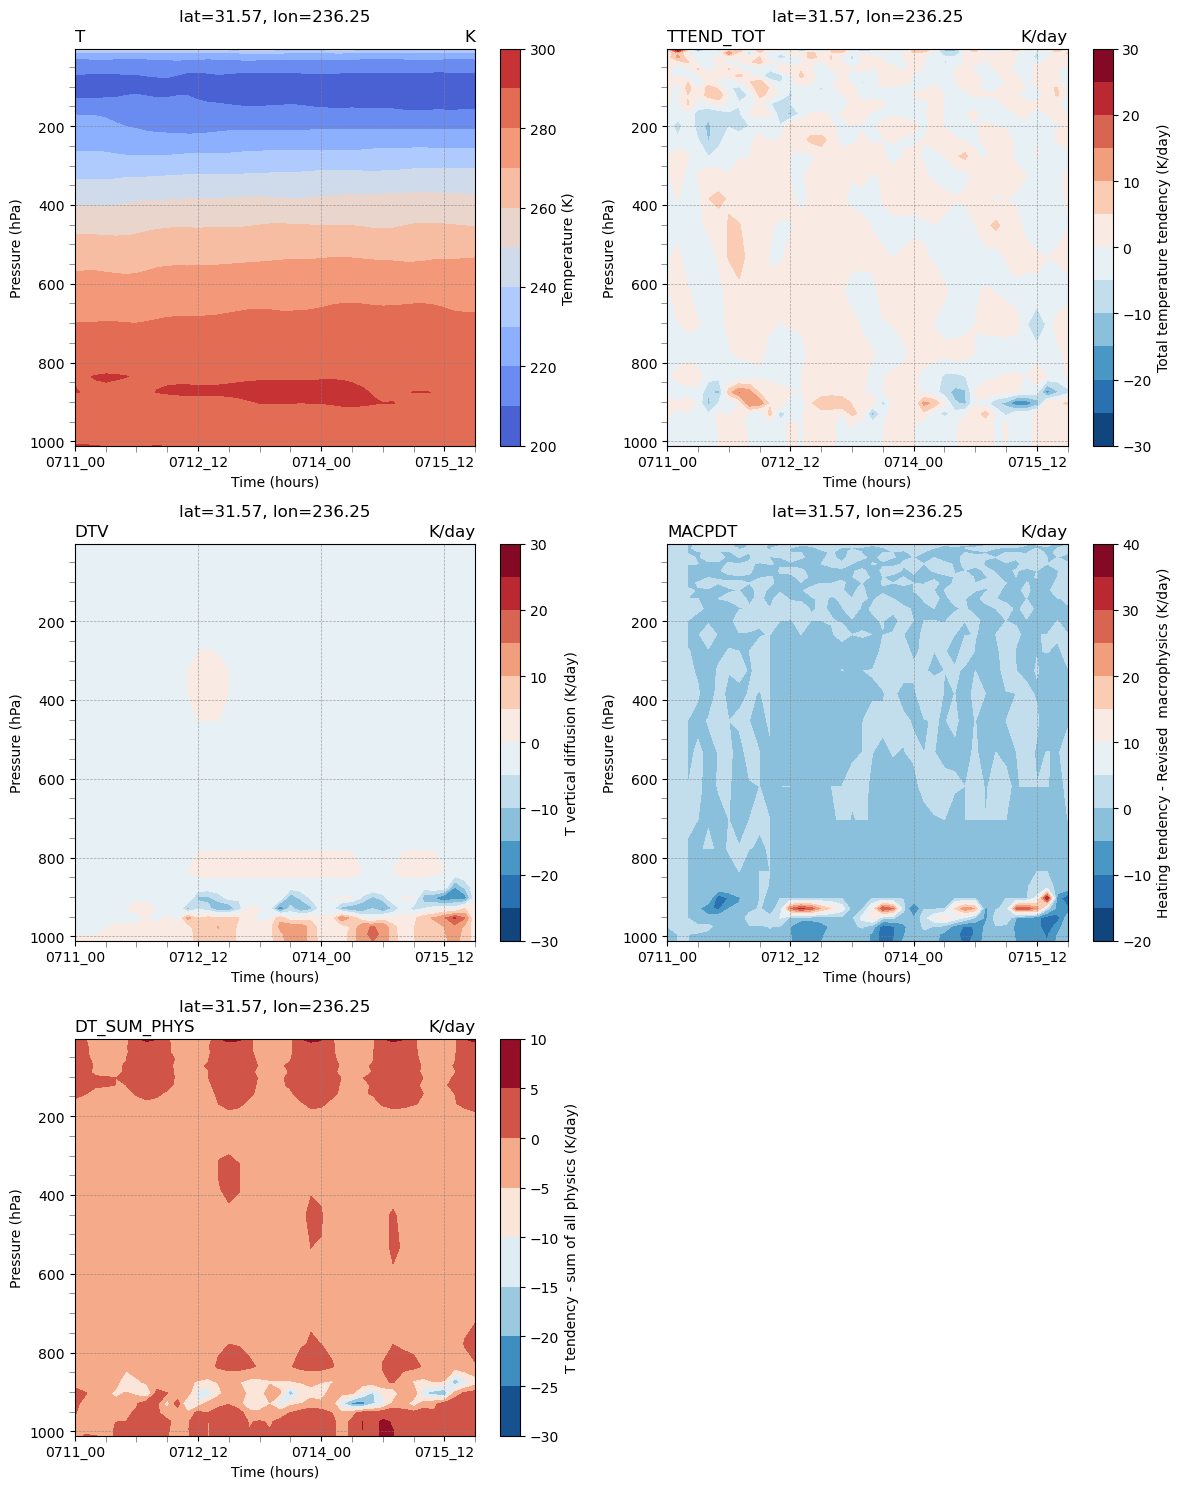

In [14]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="T")

## Plot QV

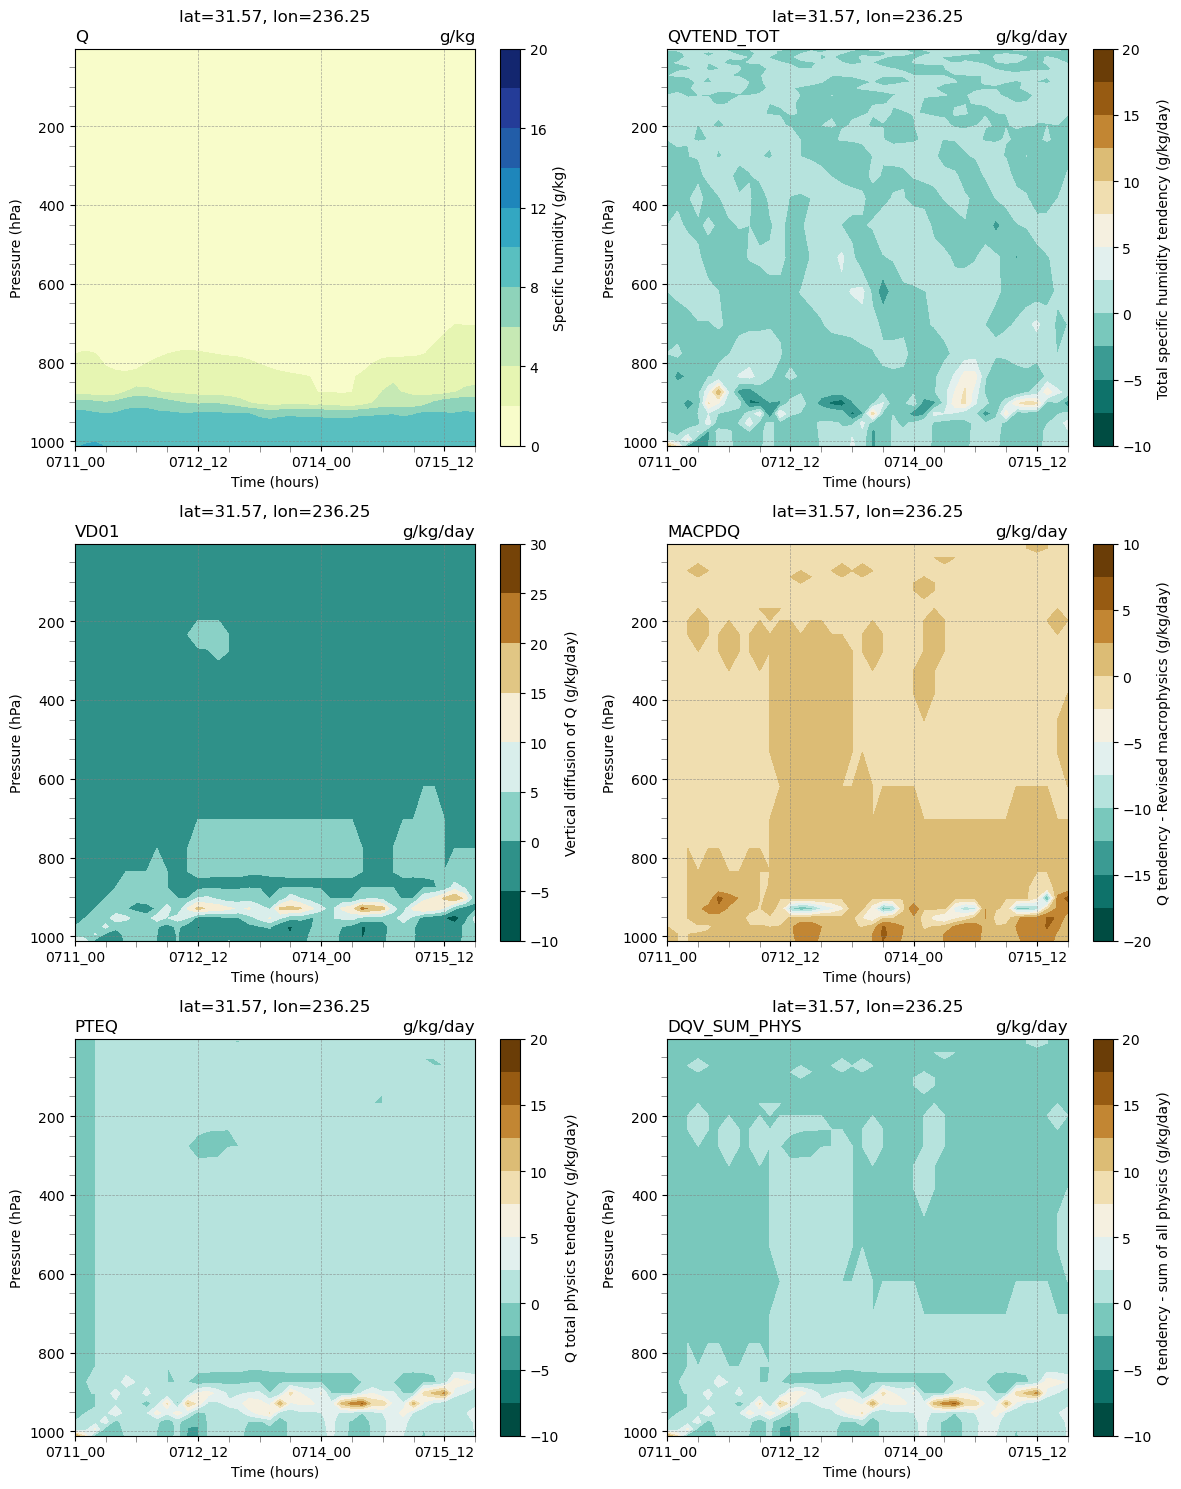

In [15]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="QV")

## Plot QL

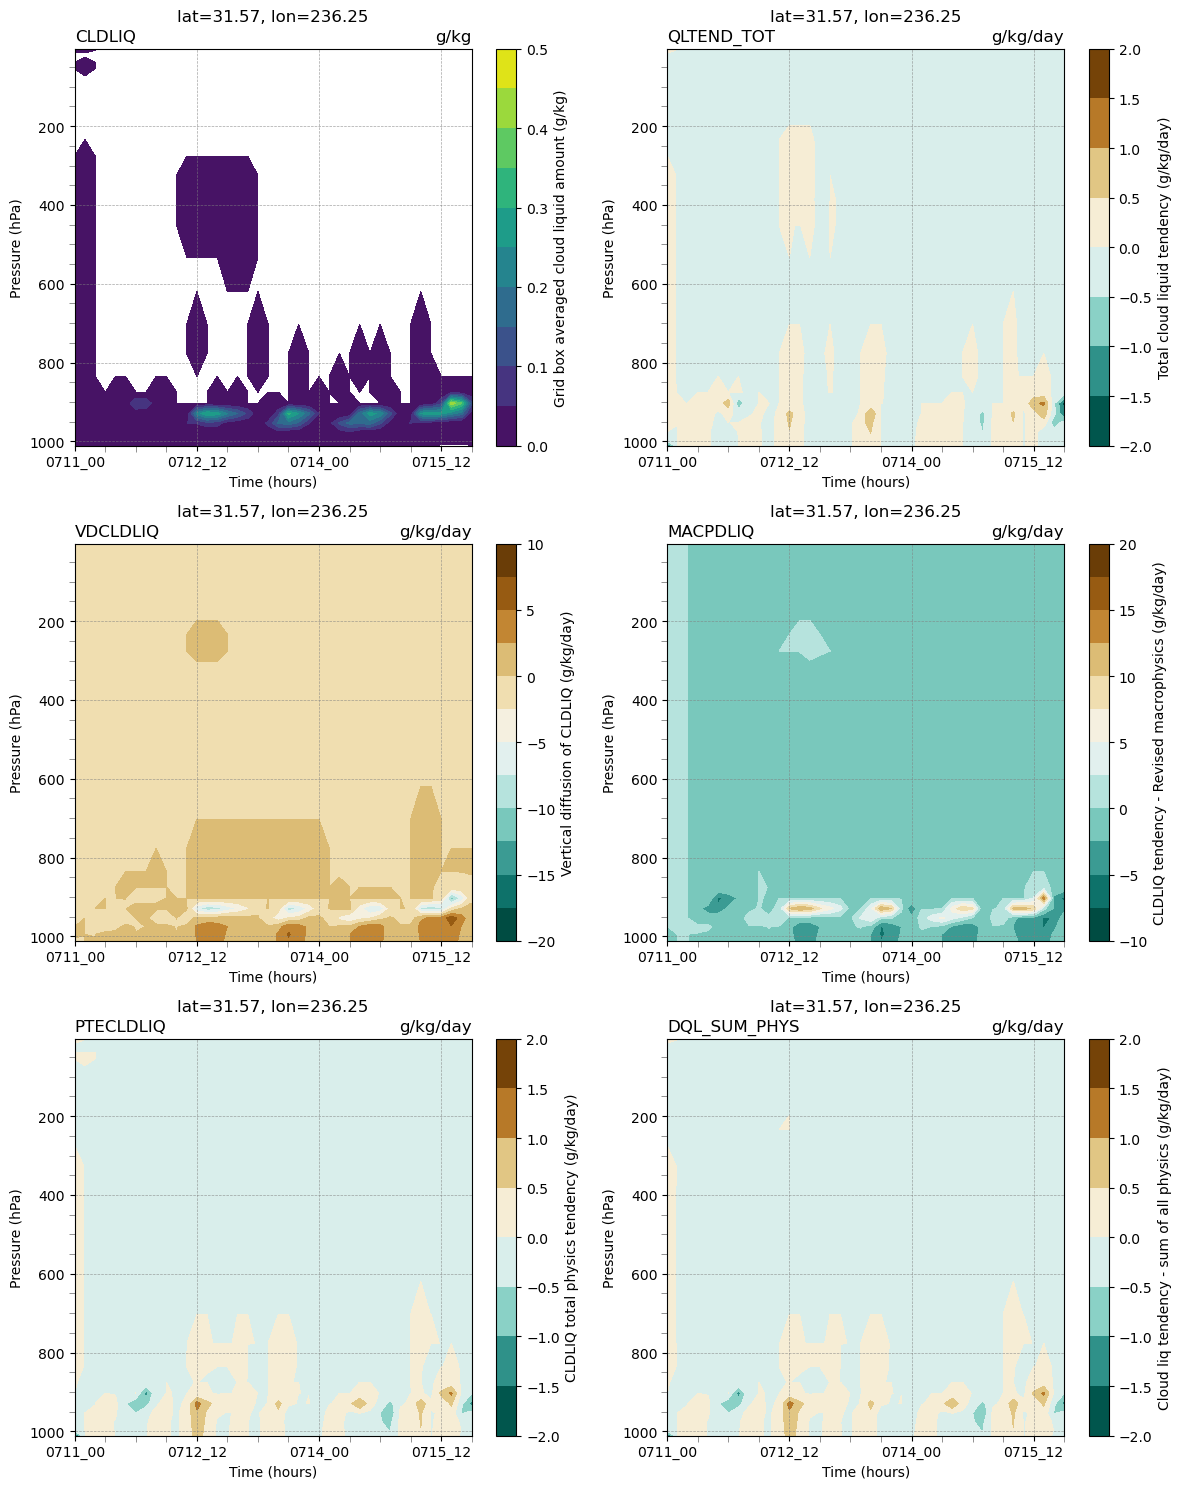

In [16]:
plot_time_lev_contour_panel(icdate, lat, lon, var_group="QL")